In [1]:
# ==========================================
# Threat Actor Profiling (Fast & Robust Version)
# ==========================================

import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings

# -------------------------------
# Silence sklearn warnings
# -------------------------------
warnings.filterwarnings('ignore')

In [2]:
# -------------------------------
# STEP 1: Load ZIP & Combine CSVs
# -------------------------------
zip_path = r"C:\Users\parva\OneDrive\Parvathy\B.Tech\4th Sem\Machine Learning\Project TAP\Threat Actor Profiling\cicids2017.zip"  # change path
dataframes = []

with zipfile.ZipFile(zip_path, 'r') as z:
    for file in z.namelist():
        if file.endswith(".csv"):
            print(f"Loading {file}...")
            with z.open(file) as f:
                df_temp = pd.read_csv(f, encoding='latin1')
                dataframes.append(df_temp)

df = pd.concat(dataframes, ignore_index=True)
print("\nCombined Dataset Shape:", df.shape)

Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
Loading Monday-WorkingHours.pcap_ISCX.csv...
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
Loading Tuesday-WorkingHours.pcap_ISCX.csv...
Loading Wednesday-workingHours.pcap_ISCX.csv...

Combined Dataset Shape: (2830743, 79)


In [3]:
# -------------------------------
# STEP 2: Sample for speed
# -------------------------------
df = df.sample(n=min(50000, len(df)), random_state=42)
print("After Sampling Shape:", df.shape)


After Sampling Shape: (50000, 79)


In [4]:
# -------------------------------
# STEP 3: Detect Label Column
# -------------------------------
df.columns = df.columns.str.strip()
possible_label_cols = [col for col in df.columns if 'label' in col.lower() or 'class' in col.lower()]
if not possible_label_cols:
    raise ValueError("No label column found!")
label_col = possible_label_cols[0]
df.rename(columns={label_col: 'Label'}, inplace=True)
print(f"Detected label column: {label_col}")

Detected label column: Label


In [5]:
# -------------------------------
# STEP 4: Drop unnecessary columns
# -------------------------------
columns_to_drop = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
for col in columns_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)


In [6]:
# -------------------------------
# STEP 5: Handle NaNs/Infs
# -------------------------------
df.replace([np.inf, -np.inf], 0, inplace=True)
df.fillna(0, inplace=True)

df['Label'] = df['Label'].astype('category')
label_mapping = dict(enumerate(df['Label'].cat.categories))
df['Label'] = df['Label'].cat.codes
print("Label Mapping:", label_mapping)

Label Mapping: {0: 'BENIGN', 1: 'Bot', 2: 'DDoS', 3: 'DoS GoldenEye', 4: 'DoS Hulk', 5: 'DoS Slowhttptest', 6: 'DoS slowloris', 7: 'FTP-Patator', 8: 'PortScan', 9: 'SSH-Patator', 10: 'Web Attack ï¿½ Brute Force', 11: 'Web Attack ï¿½ XSS'}


In [7]:
# -------------------------------
# STEP 6: Feature Engineering
# -------------------------------
if 'Total Fwd Packets' in df.columns and 'Flow Duration' in df.columns:
    df['Packets_per_sec'] = df['Total Fwd Packets'] / (df['Flow Duration'] + 1)

if 'Total Length of Fwd Packets' in df.columns and 'Flow Duration' in df.columns:
    df['Bytes_per_sec'] = df['Total Length of Fwd Packets'] / (df['Flow Duration'] + 1)

df.replace([np.inf, -np.inf], 0, inplace=True)
df.fillna(0, inplace=True)

In [8]:
# -------------------------------
# STEP 7: Split Data
# -------------------------------
X = df.drop('Label', axis=1)
y = df['Label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [9]:
# -------------------------------
# STEP 8: Train Fast Random Forest
# -------------------------------
print("Training Random Forest (fast version)...")
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
model.fit(X_train, y_train)
print("Model training complete!")

Training Random Forest (fast version)...
Model training complete!



Accuracy: 0.9948

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8068
           1       0.00      0.00      0.00         9
           2       1.00      0.99      1.00       442
           3       1.00      0.92      0.96        24
           4       0.99      1.00      0.99       813
           5       0.94      0.79      0.86        19
           6       0.95      0.95      0.95        19
           7       1.00      1.00      1.00        37
           8       0.99      1.00      0.99       543
           9       1.00      0.53      0.69        17
          10       0.00      0.00      0.00         5
          11       0.00      0.00      0.00         4

    accuracy                           0.99     10000
   macro avg       0.74      0.68      0.70     10000
weighted avg       0.99      0.99      0.99     10000



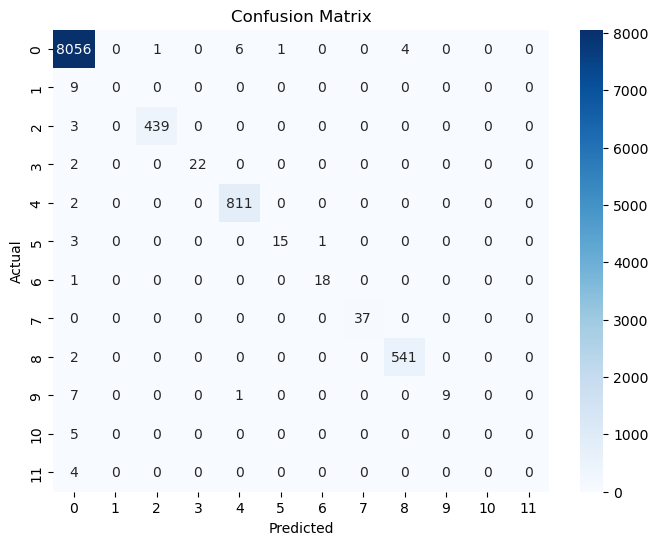

In [10]:
# -------------------------------
# STEP 9: Evaluation
# -------------------------------
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
# -------------------------------
# STEP 10: Threat Actor Profiling (All Labels Covered)
# -------------------------------
profile_map = {}
for key, value in label_mapping.items():
    value_lower = value.lower()
    if "dos" in value_lower or "ddos" in value_lower:
        profile_map[key] = "DoS Attacker (High Traffic Flooding)"
    elif "brute" in value_lower:
        profile_map[key] = "Brute Force Attacker (Repeated Attempts)"
    elif "bot" in value_lower:
        profile_map[key] = "Botnet (Automated Traffic)"
    elif "portscan" in value_lower:
        profile_map[key] = "Reconnaissance Scanner"
    elif "ftp" in value_lower:
        profile_map[key] = "FTP Attack"
    elif "ssh" in value_lower:
        profile_map[key] = "SSH Attack"
    elif "benign" in value_lower:
        profile_map[key] = "Normal User"
    elif "xss" in value_lower:
        profile_map[key] = "Web Attack (XSS)"
    else:
        profile_map[key] = "Unknown Threat"

print("\n=== Sample Threat Actor Profiles ===")
for i in range(10):
    label = y_pred[i]
    print(f"Sample {i+1}: {profile_map.get(label, 'Unknown Threat')}")



=== Sample Threat Actor Profiles ===
Sample 1: Reconnaissance Scanner
Sample 2: Normal User
Sample 3: Normal User
Sample 4: Normal User
Sample 5: Normal User
Sample 6: DoS Attacker (High Traffic Flooding)
Sample 7: Normal User
Sample 8: Reconnaissance Scanner
Sample 9: Normal User
Sample 10: Normal User


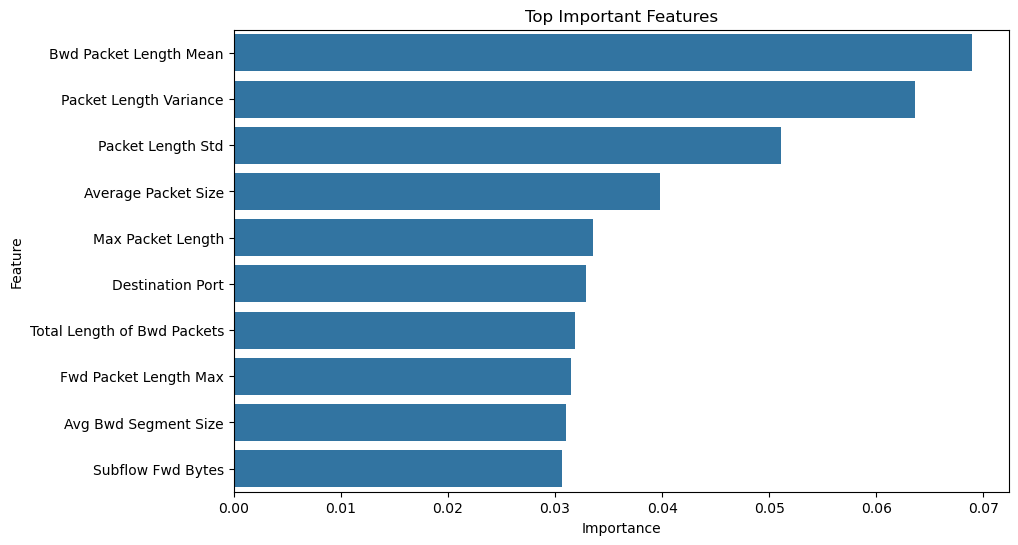


Top Features:
                         Feature  Importance
12       Bwd Packet Length Mean    0.068904
42       Packet Length Variance    0.063581
41            Packet Length Std    0.051085
52          Average Packet Size    0.039777
39            Max Packet Length    0.033525
0              Destination Port    0.032929
5   Total Length of Bwd Packets    0.031825
6         Fwd Packet Length Max    0.031532
54         Avg Bwd Segment Size    0.031032
63            Subflow Fwd Bytes    0.030619


In [12]:
# -------------------------------
# STEP 11: Feature Importance
# -------------------------------
importances = model.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(10))
plt.title("Top Important Features")
plt.show()

print("\nTop Features:\n", feat_df.head(10))